# Learning Koopman / Lifted Dynamics for the Three-Body System

Workflow:

1. Import dependencies and helper functions
2. Define the lifted Koopman neural modules
3. Generate trajectory data from the three-body system
4. Set training hyperparameters
5. Train the lifted Koopman model
6. Perform long-term prediction
7. Visualize true and predicted trajectories

Before running this notebook, make sure that `functions.py` is in the same project directory or available in the Python path. The helper functions/classes `fix_config`, `threebody`, and `odeint` are expected to be defined there.

## 1. Import dependencies

In [1]:
import os
from functions import *

D:\Anaconda\envs\zjd3.7.6\lib\site-packages\tqdm-4.64.0-py3.7.egg\tqdm\auto.py:22: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 2. Define neural network modules

`K_Net` learns a linear evolution operator in the lifted space. Its weight matrix is constrained to be orthogonal using `geotorch.orthogonal`.

`lift_Net` maps the original 12-dimensional three-body state into a higher-dimensional lifted representation. `Decoder` maps the lifted representation back to the original physical coordinates.

In [2]:
class K_Net(torch.nn.Module):
    def __init__(self, n_input, n_output):
        super(K_Net, self).__init__()
        self.recurrent_kernel = nn.Linear(n_input, n_output, bias=False)
        geotorch.orthogonal(self.recurrent_kernel, "weight")
        self.reset_parameters()

    def reset_parameters(self):
        M = self.recurrent_kernel.parametrizations.weight[0]
        self.recurrent_kernel.weight = M.sample("uniform")

    def forward(self, data):
        return self.recurrent_kernel(data)


class lift_Net(torch.nn.Module):
    def __init__(self, n_input, n_hidden, n_output):
        super(lift_Net, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(n_input, n_hidden),
            nn.Tanh(),
            nn.Linear(n_hidden, n_hidden),
            nn.Tanh(),
            nn.Linear(n_hidden, n_hidden),
            nn.Tanh(),
            nn.Linear(n_hidden, n_hidden),
            nn.Tanh(),
            nn.Linear(n_hidden, n_hidden),
            nn.Tanh(),
            nn.Linear(n_hidden, n_hidden),
            nn.Tanh(),
            nn.Linear(n_hidden, n_output),
        )

        for m in self.net.modules():
            if isinstance(m, nn.Linear):
                nn.init.normal_(m.weight, mean=0, std=0.1)
                nn.init.constant_(m.bias, val=0)

        self.k = torch.tensor(2.0, requires_grad=True)
        self.v = torch.randn([12 + lift_d, q], requires_grad=True)

    def forward(self, data):
        out = self.net(data)
        return out


class Decoder(nn.Module):
    def __init__(self):
        super(Decoder, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(12 + lift_d, 120),
            nn.Tanh(),
            nn.Linear(120, 120),
            nn.Tanh(),
            nn.Linear(120, 12),
        )

        for m in self.net.modules():
            if isinstance(m, nn.Linear):
                nn.init.normal_(m.weight, mean=0, std=0.1)
                nn.init.constant_(m.bias, val=0)

    def forward(self, y):
        return self.net(y)

## 3. Generate trajectory data from the three-body system

The initial state is generated by `fix_config()`. The clean trajectory `true_y` is obtained by numerically integrating the three-body ODE. Gaussian observation noise is added later during training.

In [3]:
y0 = torch.from_numpy(fix_config()).view([1, 12])
t = torch.linspace(0, 5, 100)
true_y = odeint(threebody(), y0, t, atol=1e-8, rtol=1e-8)[:, 0, :]

print(torch.max(torch.sum(true_y**2, dim=1)))

tensor(4.3545)


## 4. Hyperparameter settings

This cell specifies the observation noise level, lifted dimension, orthogonality-constraint dimension, and input/output dimensions of the lifted dynamics.

In [4]:
sigma = 0.03
lift_d = 19
q = 15
D_in = 12 + lift_d
H1 = 10 * D_in
D_out = 12 + lift_d

## 5. Model training

The loss contains four components:

1. One-step prediction error in the lifted space
2. Reconstruction error through the decoder
3. Constraint enforcing approximately constant lifted-state norm
4. Orthogonality-related constraints for the auxiliary directions

In [5]:
out_iters = 0
eigen_list = []
os.makedirs('./data/feature_data', exist_ok=True)

while out_iters < 1:
    start = timeit.default_timer()
    torch.manual_seed(369)
    np.random.seed(369)

    model = K_Net(D_in, D_out)
    y = true_y + torch.from_numpy(np.random.normal(0, sigma, true_y.shape))
    g1 = lift_Net(12, 120, 12 + lift_d)
    Dec = Decoder()

    i = 0
    max_iters = 10000
    learning_rate = 0.0005
    optimizer = torch.optim.Adam(
        [i for i in model.parameters()] +
        [i for i in g1.parameters()] +
        [g1.k] +
        [g1.v] +
        [i for i in Dec.parameters()],
        lr=learning_rate,
    )

    while i < max_iters:
        lift_y = g1(y)
        dec_y = Dec(lift_y)
        X1, X2 = lift_y[:-1], lift_y[1:]

        v = g1.v / torch.sqrt(torch.sum(g1.v**2, dim=0))
        V = torch.mm(v.T, v) - torch.eye(q)

        loss = (
            torch.sum((X2 - model(X1))**2)
            + torch.sum((dec_y - y)**2)
            + torch.sum((torch.sum(lift_y**2, dim=1) - g1.k)**2)
            + torch.sum(torch.mm(lift_y, v)**2)
            + torch.sum(V**2)
        )

        print(out_iters, i, "loss=", loss.item(), g1.k)
        optimizer.zero_grad()
        loss.backward(retain_graph=True)
        optimizer.step()

        if loss <= 1e-4:
            break
        i += 1

    stop = timeit.default_timer()
    K = model.recurrent_kernel.weight.detach().numpy()
    enc = g1(true_y).detach().numpy()

    np.save('./data/feature_data/koopman_{}_{}'.format(D_in, sigma), K)
    np.save('./data/feature_data/enc_{}_{}'.format(D_in, sigma), enc)
    print('Total time: ', stop - start)
    out_iters += 1

0 0 loss= 1861.0943875911385 tensor(2., requires_grad=True)
0 1 loss= 942.552435058199 tensor(2.0005, requires_grad=True)
0 2 loss= 758.4280887031842 tensor(2.0008, requires_grad=True)
0 3 loss= 716.4009050926562 tensor(2.0007, requires_grad=True)
0 4 loss= 695.7256875613296 tensor(2.0005, requires_grad=True)
0 5 loss= 686.4654308897328 tensor(2.0003, requires_grad=True)
0 6 loss= 679.0879558119939 tensor(2.0000, requires_grad=True)
0 7 loss= 653.6377916898804 tensor(1.9997, requires_grad=True)
0 8 loss= 608.383406674247 tensor(1.9994, requires_grad=True)
0 9 loss= 558.8885950131877 tensor(1.9991, requires_grad=True)
0 10 loss= 517.7051352326439 tensor(1.9989, requires_grad=True)
0 11 loss= 487.3246441871217 tensor(1.9986, requires_grad=True)
0 12 loss= 463.55365241424835 tensor(1.9984, requires_grad=True)
0 13 loss= 440.618823716504 tensor(1.9981, requires_grad=True)
0 14 loss= 414.8991147270039 tensor(1.9979, requires_grad=True)
0 15 loss= 386.04318820498446 tensor(1.9976, requires_g

0 148 loss= 12.387260422547238 tensor(1.9854, requires_grad=True)
0 149 loss= 12.286412251501968 tensor(1.9854, requires_grad=True)
0 150 loss= 12.18746800156092 tensor(1.9853, requires_grad=True)
0 151 loss= 12.090382859998444 tensor(1.9853, requires_grad=True)
0 152 loss= 11.995111606125754 tensor(1.9853, requires_grad=True)
0 153 loss= 11.901626219093743 tensor(1.9852, requires_grad=True)
0 154 loss= 11.8098919274351 tensor(1.9852, requires_grad=True)
0 155 loss= 11.719878141291172 tensor(1.9852, requires_grad=True)
0 156 loss= 11.631555812085905 tensor(1.9852, requires_grad=True)
0 157 loss= 11.544882283820275 tensor(1.9851, requires_grad=True)
0 158 loss= 11.45982044379044 tensor(1.9851, requires_grad=True)
0 159 loss= 11.3763376593185 tensor(1.9851, requires_grad=True)
0 160 loss= 11.294406306092483 tensor(1.9850, requires_grad=True)
0 161 loss= 11.21400187567423 tensor(1.9850, requires_grad=True)
0 162 loss= 11.1350883428942 tensor(1.9850, requires_grad=True)
0 163 loss= 11.0576

0 276 loss= 7.221116500937198 tensor(1.9835, requires_grad=True)
0 277 loss= 7.207923686176748 tensor(1.9835, requires_grad=True)
0 278 loss= 7.194880214735269 tensor(1.9835, requires_grad=True)
0 279 loss= 7.181983323621432 tensor(1.9835, requires_grad=True)
0 280 loss= 7.169230304768763 tensor(1.9835, requires_grad=True)
0 281 loss= 7.1566185038889385 tensor(1.9835, requires_grad=True)
0 282 loss= 7.144145319465447 tensor(1.9835, requires_grad=True)
0 283 loss= 7.131808201612087 tensor(1.9835, requires_grad=True)
0 284 loss= 7.119604651014475 tensor(1.9835, requires_grad=True)
0 285 loss= 7.107532217872372 tensor(1.9835, requires_grad=True)
0 286 loss= 7.095588500958128 tensor(1.9835, requires_grad=True)
0 287 loss= 7.083771146585433 tensor(1.9835, requires_grad=True)
0 288 loss= 7.072077847632026 tensor(1.9835, requires_grad=True)
0 289 loss= 7.060506342583649 tensor(1.9835, requires_grad=True)
0 290 loss= 7.049054414617234 tensor(1.9835, requires_grad=True)
0 291 loss= 7.0377198906

0 404 loss= 6.182919600946479 tensor(1.9830, requires_grad=True)
0 405 loss= 6.177378359794675 tensor(1.9830, requires_grad=True)
0 406 loss= 6.1718549282796165 tensor(1.9830, requires_grad=True)
0 407 loss= 6.166349051704312 tensor(1.9830, requires_grad=True)
0 408 loss= 6.160860479615147 tensor(1.9830, requires_grad=True)
0 409 loss= 6.155388965725432 tensor(1.9830, requires_grad=True)
0 410 loss= 6.149934267840568 tensor(1.9830, requires_grad=True)
0 411 loss= 6.144496147784693 tensor(1.9830, requires_grad=True)
0 412 loss= 6.139074371328816 tensor(1.9830, requires_grad=True)
0 413 loss= 6.13366870812035 tensor(1.9830, requires_grad=True)
0 414 loss= 6.128278931614113 tensor(1.9830, requires_grad=True)
0 415 loss= 6.122904819004669 tensor(1.9830, requires_grad=True)
0 416 loss= 6.117546151160054 tensor(1.9830, requires_grad=True)
0 417 loss= 6.11220271255676 tensor(1.9830, requires_grad=True)
0 418 loss= 6.106874291216074 tensor(1.9830, requires_grad=True)
0 419 loss= 6.101560678641

0 542 loss= 5.518453010690095 tensor(1.9826, requires_grad=True)
0 543 loss= 5.514070606864168 tensor(1.9826, requires_grad=True)
0 544 loss= 5.509691924237763 tensor(1.9826, requires_grad=True)
0 545 loss= 5.505316935361661 tensor(1.9826, requires_grad=True)
0 546 loss= 5.500945613226019 tensor(1.9826, requires_grad=True)
0 547 loss= 5.496577931253459 tensor(1.9826, requires_grad=True)
0 548 loss= 5.492213863292244 tensor(1.9826, requires_grad=True)
0 549 loss= 5.487853383609591 tensor(1.9826, requires_grad=True)
0 550 loss= 5.483496466885062 tensor(1.9826, requires_grad=True)
0 551 loss= 5.4791430882040695 tensor(1.9826, requires_grad=True)
0 552 loss= 5.474793223051474 tensor(1.9826, requires_grad=True)
0 553 loss= 5.4704468473053 tensor(1.9826, requires_grad=True)
0 554 loss= 5.466103937230512 tensor(1.9826, requires_grad=True)
0 555 loss= 5.461764469472928 tensor(1.9826, requires_grad=True)
0 556 loss= 5.457428421053203 tensor(1.9826, requires_grad=True)
0 557 loss= 5.453095769360

...

0 9388 loss= 0.21449511063454246 tensor(1.8603, requires_grad=True)
0 9389 loss= 0.21340057413488903 tensor(1.8603, requires_grad=True)
0 9390 loss= 0.213327214123716 tensor(1.8603, requires_grad=True)
0 9391 loss= 0.21221267169311647 tensor(1.8603, requires_grad=True)
0 9392 loss= 0.21100615830847305 tensor(1.8603, requires_grad=True)
0 9393 loss= 0.21211164953289313 tensor(1.8603, requires_grad=True)
0 9394 loss= 0.2142329029186633 tensor(1.8603, requires_grad=True)
0 9395 loss= 0.214500562022291 tensor(1.8602, requires_grad=True)
0 9396 loss= 0.21525058377842832 tensor(1.8602, requires_grad=True)
0 9397 loss= 0.21942727304372892 tensor(1.8602, requires_grad=True)
0 9398 loss= 0.22727498785472616 tensor(1.8602, requires_grad=True)
0 9399 loss= 0.23685845471326206 tensor(1.8602, requires_grad=True)
0 9400 loss= 0.25221061018405455 tensor(1.8602, requires_grad=True)
0 9401 loss= 0.27425458983274564 tensor(1.8601, requires_grad=True)
0 9402 loss= 0.3110779168041817 tensor(1.8602, requir

0 9520 loss= 0.26776554438257355 tensor(1.8582, requires_grad=True)
0 9521 loss= 0.2877585249459734 tensor(1.8582, requires_grad=True)
0 9522 loss= 0.3149987263681176 tensor(1.8582, requires_grad=True)
0 9523 loss= 0.3521091520429943 tensor(1.8582, requires_grad=True)
0 9524 loss= 0.4006799819590909 tensor(1.8581, requires_grad=True)
0 9525 loss= 0.4609916415389089 tensor(1.8581, requires_grad=True)
0 9526 loss= 0.5271273507663471 tensor(1.8581, requires_grad=True)
0 9527 loss= 0.5865242413196348 tensor(1.8581, requires_grad=True)
0 9528 loss= 0.6157576671779379 tensor(1.8581, requires_grad=True)
0 9529 loss= 0.5905347352181726 tensor(1.8581, requires_grad=True)
0 9530 loss= 0.5025409473471912 tensor(1.8580, requires_grad=True)
0 9531 loss= 0.37820910977116495 tensor(1.8580, requires_grad=True)
0 9532 loss= 0.2754794936880712 tensor(1.8580, requires_grad=True)
0 9533 loss= 0.24067446563740855 tensor(1.8580, requires_grad=True)
0 9534 loss= 0.27046816898153725 tensor(1.8580, requires_gr

0 9652 loss= 0.7963015164376369 tensor(1.8563, requires_grad=True)
0 9653 loss= 0.7413591978312587 tensor(1.8561, requires_grad=True)
0 9654 loss= 0.6306083400765939 tensor(1.8562, requires_grad=True)
0 9655 loss= 0.3978129869249332 tensor(1.8561, requires_grad=True)
0 9656 loss= 0.24529096996382857 tensor(1.8561, requires_grad=True)
0 9657 loss= 0.2368712984644898 tensor(1.8561, requires_grad=True)
0 9658 loss= 0.32425898433135075 tensor(1.8560, requires_grad=True)
0 9659 loss= 0.3880465708795741 tensor(1.8560, requires_grad=True)
0 9660 loss= 0.34425008008371255 tensor(1.8559, requires_grad=True)
0 9661 loss= 0.2733416672775483 tensor(1.8560, requires_grad=True)
0 9662 loss= 0.24229284426409006 tensor(1.8559, requires_grad=True)
0 9663 loss= 0.262444086528188 tensor(1.8559, requires_grad=True)
0 9664 loss= 0.2856230568725835 tensor(1.8559, requires_grad=True)
0 9665 loss= 0.2761006036862125 tensor(1.8558, requires_grad=True)
0 9666 loss= 0.2529368230355839 tensor(1.8558, requires_gra

0 9784 loss= 0.26339827321382414 tensor(1.8540, requires_grad=True)
0 9785 loss= 0.28393188489410737 tensor(1.8540, requires_grad=True)
0 9786 loss= 0.2510787518818163 tensor(1.8540, requires_grad=True)
0 9787 loss= 0.24643254434633435 tensor(1.8539, requires_grad=True)
0 9788 loss= 0.2759116275477262 tensor(1.8539, requires_grad=True)
0 9789 loss= 0.26099039261107 tensor(1.8539, requires_grad=True)
0 9790 loss= 0.23782249720727697 tensor(1.8539, requires_grad=True)
0 9791 loss= 0.24485563500172725 tensor(1.8539, requires_grad=True)
0 9792 loss= 0.23806939708096397 tensor(1.8538, requires_grad=True)
0 9793 loss= 0.2256625334410679 tensor(1.8539, requires_grad=True)
0 9794 loss= 0.23134408878808457 tensor(1.8538, requires_grad=True)
0 9795 loss= 0.22705338536283493 tensor(1.8538, requires_grad=True)
0 9796 loss= 0.21281017799623947 tensor(1.8538, requires_grad=True)
0 9797 loss= 0.21495425975688093 tensor(1.8538, requires_grad=True)
0 9798 loss= 0.21721794834844554 tensor(1.8538, requir

0 9914 loss= 0.19336378380455466 tensor(1.8521, requires_grad=True)
0 9915 loss= 0.19369276176105504 tensor(1.8521, requires_grad=True)
0 9916 loss= 0.19439520347442577 tensor(1.8521, requires_grad=True)
0 9917 loss= 0.1957813997627666 tensor(1.8521, requires_grad=True)
0 9918 loss= 0.19822347805607873 tensor(1.8521, requires_grad=True)
0 9919 loss= 0.20257523971244434 tensor(1.8521, requires_grad=True)
0 9920 loss= 0.2099510068613393 tensor(1.8520, requires_grad=True)
0 9921 loss= 0.22324539781626804 tensor(1.8520, requires_grad=True)
0 9922 loss= 0.24559972134890234 tensor(1.8520, requires_grad=True)
0 9923 loss= 0.2869858004250735 tensor(1.8520, requires_grad=True)
0 9924 loss= 0.35420814627130137 tensor(1.8520, requires_grad=True)
0 9925 loss= 0.47939061859554116 tensor(1.8520, requires_grad=True)
0 9926 loss= 0.6566663163694337 tensor(1.8519, requires_grad=True)
0 9927 loss= 0.9610590505331952 tensor(1.8520, requires_grad=True)
0 9928 loss= 1.2177859329951068 tensor(1.8518, requir

## 6. Long-term prediction

After training, we iteratively apply the learned Koopman operator in the lifted space and then decode the predicted lifted states back to the original 12-dimensional state space.

In [6]:
n = 1800
lift_y = g1(true_y)
dec_y = Dec(lift_y)[:-1]

y_np = y.detach().numpy()
dec_y_np = dec_y.detach().numpy()

Y_lifted = np.zeros([n, len(K)])
Y_lifted[0, :] = lift_y.detach().numpy()[0, :]

for i in range(n - 1):
    x = Y_lifted[i, :].reshape(-1, 1)
    Y_lifted[i + 1, :] = np.matmul(K, x).T[0]

pred_y = Dec(torch.from_numpy(Y_lifted)).detach().numpy()

## 7. Trajectory visualization

This plot compares the true and predicted trajectories in the coordinate planes of the first two bodies.

(1000, 12) (1800, 12)


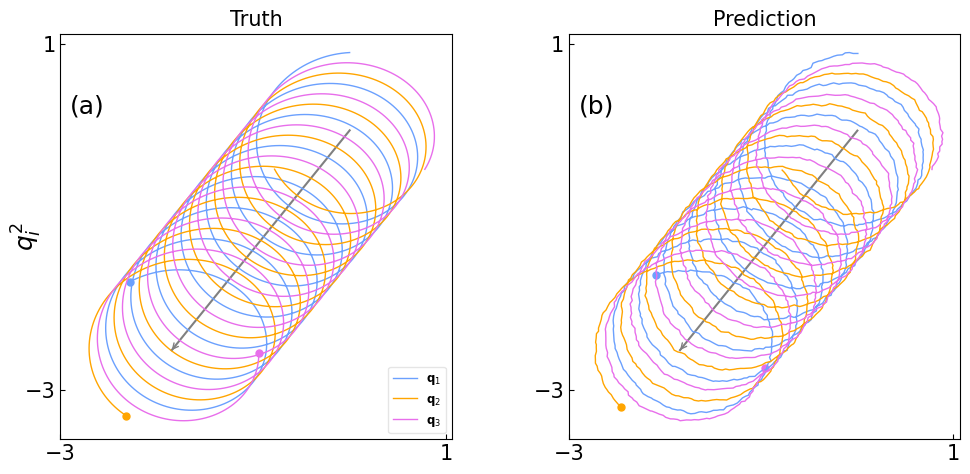

In [20]:
global_lw = 1.0
legendsize = 7
colors = [
    [107/256,	161/256,255/256], # #6ba1ff
    [255/255, 165/255, 0],
    [233/256,	110/256, 236/256], # #e96eec
    # [0.6, 0.6, 0.2],  # olive
    # [0.5333333333333333, 0.13333333333333333, 0.3333333333333333],  # wine
    # [0.8666666666666667, 0.8, 0.4666666666666667],  # sand
    # [223/256,	73/256,	54/256], # #df4936
    [0.6, 0.4, 0.8], # amethyst
    [0.0, 0.0, 1.0], # ao
    [0.55, 0.71, 0.0], # applegreen
    # [0.4, 1.0, 0.0], # brightgreen
    [0.99, 0.76, 0.8], # bubblegum
    [0.93, 0.53, 0.18], # cadmiumorange
    [11/255, 132/255, 147/255], # deblue
    [204/255, 119/255, 34/255], # {ocra}
]
def subplot(data, timeline, leg=False):
    co1 = colors[0]
    co2 = colors[1]
    co3 = colors[2]
    width = global_lw
    s = 25
    style = 'solid'
    plt.plot(timeline[:,0],timeline[:,1],c='grey')
    plt.plot(data[:,0],data[:,1],color=co1,ls=style,lw=width, label=r'$\mathbf{q}_1$')
    plt.plot(data[:,2],data[:,3],color=co2,ls=style,lw=width, label=r'$\mathbf{q}_2$')
    plt.plot(data[:,4],data[:,5],color=co3,ls=style,lw=width, label=r'$\mathbf{q}_3$')
    plt.annotate("",
                xy=(timeline[-1,0], timeline[-1,1]),
                xytext=(timeline[-2,0],timeline[-2,1]),
                # xycoords="figure points",
                arrowprops=dict(arrowstyle="->", color="grey"))
    plt.scatter(data[-1,0],data[-1,1],color=co1,marker='o',s=s)
    plt.scatter(data[-1,2], data[-1,3], color=co2, marker='o', s=s)
    plt.scatter(data[-1, 4], data[-1, 5], color=co3, marker='o', s=s)

    if leg:
        plt.legend(ncol=1, fontsize=8.5,framealpha=0.5,loc=4)
def plot():
    import matplotlib
    plt.rcParams['ytick.direction'] = 'in'
    plt.rcParams['xtick.direction'] = 'in'
    fontsize = 18
    labelsize= 15

    '''
    data size: (1800,12) 
    1800: time interval on [0,90], 1800 uniform samples
    12:   state q_x1,q_y1,q_x2,q_y2,q_x3,q_y3,p_x1,p_y1,p_x2,p_y2,p_x3,p_y3
    here we choose time intrval on [0,50] for plot, that is, data[:1000,:]
    '''
    true = np.load('./data/true_y_90_1800.npy')[:1000]
    pred = pred_y[:1000]
    print(true.shape,pred_y.shape)

    '''
    3D space-time projection to 2D plane 
    '''
    np.random.seed(369)
    t = np.linspace(0, 50, 1000)
    A = rotate3d(-np.pi/50,np.pi*0.3)
    t_true,timeline = transform(A,true+np.random.normal(0,0.00,true.shape),t)
    t_pred, pred_timeline = transform(A, pred, t)

    '''
    plot
    '''

    fig, axs = plt.subplots(2, 4)
    fig.set_figheight(5)
    fig.set_figwidth(10)
    plt.subplots_adjust(left=0.05, bottom=0.1, right=0.95, top=0.91, hspace=0.4, wspace=0.3)
    labelpad_x = -7
    labelpad_y = -14
    plt.subplot(121)
    subplot(t_true,timeline, leg=True)
    plt.xticks([-3,1],fontsize=labelsize)
    plt.yticks([-3,1],fontsize=labelsize)
    plt.ylabel(r'$q_i^2$', fontsize=fontsize, labelpad=labelpad_y)
    plt.title('Truth',fontsize=labelsize)
    plt.text(-2.9,0.2,'(a)',fontsize=fontsize)
    
    plt.subplot(122)
    subplot(t_pred,timeline, leg=False)
    plt.xticks([-3,1],fontsize=labelsize)
    plt.yticks([-3,1],fontsize=labelsize)
    plt.title('Prediction', fontsize=labelsize) #Length=100
    plt.text(-2.9, 0.2, '(b)', fontsize=fontsize)



    plt.show()
plot()